In [1]:
import random
import gymnasium as gym
import numpy as np
from tqdm import tqdm
import torch.nn as nn
import torch
import torch.nn.functional as F
from torch.distributions import Normal
import matplotlib.pyplot as plt
from collections import deque
import rl_utils

In [2]:
class ReplayMemory:
    def __init__(self, maxlen):
        self.buffer = deque(maxlen=maxlen)

    def add(self, state, action, reward, next_state, terminated):
        self.buffer.append((state, action, reward, next_state, terminated))

    def size(self):
        return len(self.buffer)

    def sample(self, size):
        transitions = random.sample(self.buffer, k=size)
        states, actions, rewards, next_states, terminated = zip(*transitions)
        return np.array(states), np.array(actions), rewards, np.array(next_states), terminated

In [3]:
class PolicyNetContinuous(torch.nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim, action_bound):
        super().__init__()
        self.action_bound = action_bound
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.mu = nn.Linear(hidden_dim, action_dim)
        self.sigma = nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        mean = self.mu(x)
        std = F.softplus(self.sigma(x))
        action_dist = Normal(mean, std)
        normal_sample = action_dist.rsample()
        log_prob = action_dist.log_prob(normal_sample)
        action = torch.tanh(normal_sample)
        action_log_prob = log_prob - torch.log(1 - torch.tanh(action).pow(2) + 1e-7)  # change of variables for tanh
        action = action * self.action_bound
        return action, action_log_prob


class QValueNetContinuous(torch.nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim):
        super().__init__()
        self.fc1 = nn.Linear(state_dim + action_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, 1)

    def forward(self, state, action):
        x = torch.cat([state, action], dim=-1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


In [4]:
class SACContinuous:
    def __init__(self, state_dim, hidden_dim, action_dim, action_bound, actor_lr, critic_lr, alpha_lr, gamma, tau, target_entropy, device):
        self.actor = PolicyNetContinuous(state_dim, hidden_dim, action_dim, action_bound).to(device)
        self.critic_1 = QValueNetContinuous(state_dim, hidden_dim, action_dim).to(device)
        self.critic_2 = QValueNetContinuous(state_dim, hidden_dim, action_dim).to(device)
        self.target_critic_1 = QValueNetContinuous(state_dim, hidden_dim, action_dim).to(device)
        self.target_critic_2 = QValueNetContinuous(state_dim, hidden_dim, action_dim).to(device)

        self.target_critic_1.load_state_dict(self.critic_1.state_dict())
        self.target_critic_2.load_state_dict(self.critic_2.state_dict())

        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(), lr=actor_lr)
        self.critic_1_optimizer = torch.optim.Adam(self.critic_1.parameters(), lr=critic_lr)
        self.critic_2_optimizer = torch.optim.Adam(self.critic_2.parameters(), lr=critic_lr)

        # Using log alpha makes training more stable
        self.log_alpha = torch.tensor(np.log(0.01), dtype=torch.float)
        self.log_alpha.requires_grad = True
        self.log_alpha_optimizer = torch.optim.Adam([self.log_alpha], lr=alpha_lr) # Adam expects a list of parameters, not a single tensor

        self.gamma = gamma
        self.tau = tau
        self.target_entropy = target_entropy
        self.device = device

    def take_action(self, state):
        state = torch.tensor([state], dtype=torch.float).to(self.device)
        action = self.actor(state)[0]
        return action[0].detach().cpu().numpy() # Removes the batch dimension

    def calc_target(self, rewards, next_states, dones):
        actions, log_probs = self.actor(next_states)
        q1_value = self.target_critic_1(next_states, actions)
        q2_value = self.target_critic_2(next_states, actions)
        targets = rewards + self.gamma * (1 - dones) * (torch.min(q1_value, q2_value) - self.log_alpha.exp() * log_probs)
        return targets

    def soft_update(self,
        network: QValueNetContinuous,
        target_network: QValueNetContinuous
    ) -> None:
        for (param, target_param) in zip(network.parameters(), target_network.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data) # Using data disables gradients

    def update(self, transition_dict):
        states = torch.tensor(transition_dict['states'], dtype=torch.float).to(self.device)
        actions = torch.tensor(transition_dict['actions'], dtype=torch.float).view(-1, 1).to(self.device)
        rewards = torch.tensor(transition_dict['rewards'], dtype=torch.float).view(-1, 1).to(self.device)
        next_states = torch.tensor(transition_dict['next_states'], dtype=torch.float).to(self.device)
        dones = torch.tensor(transition_dict['dones'], dtype=torch.float).view(-1, 1).to(self.device)
        rewards = (rewards + 8.0) / 8.0

        action_values_1 = self.critic_1(states, actions)
        action_values_2 = self.critic_2(states, actions)
        targets = self.calc_target(rewards, next_states, dones)
        critic_loss_1 = F.mse_loss(action_values_1, targets.detach())
        critic_loss_2 = F.mse_loss(action_values_2, targets.detach())

        self.critic_1_optimizer.zero_grad()
        self.critic_2_optimizer.zero_grad()
        critic_loss_1.backward()
        critic_loss_2.backward()
        self.critic_1_optimizer.step()
        self.critic_2_optimizer.step()

        cur_actions, log_probs = self.actor(states)
        q1_value = self.critic_1(states, cur_actions)
        q2_value = self.critic_2(states, cur_actions)
        actor_loss = -(torch.mean(torch.min(q1_value, q2_value) - self.log_alpha.exp() * log_probs))

        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        alpha_loss = torch.mean(-log_probs - self.target_entropy).detach() * self.log_alpha.exp()
        self.log_alpha_optimizer.zero_grad()
        alpha_loss.backward()
        self.log_alpha_optimizer.step()

        self.soft_update(self.critic_1, self.target_critic_1)
        self.soft_update(self.critic_2, self.target_critic_2)

In [5]:
env_name = 'Pendulum-v1'
env = gym.make(env_name)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
action_bound = env.action_space.high[0]

random.seed(0)
np.random.seed(0)
env.reset(seed=0)
torch.manual_seed(0)

actor_lr = 3e-4
critic_lr = 3e-3
alpha_lr = 3e-4
num_episodes = 100
hidden_dim = 128
gamma = 0.99
tau = 0.005
buffer_size = 100000
minimal_size = 1000
batch_size = 64
target_entropy = -env.action_space.shape[0]
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')

replay_buffer = ReplayMemory(buffer_size)
agent = SACContinuous(state_dim, hidden_dim, action_dim, action_bound, actor_lr, critic_lr, alpha_lr, gamma, tau, target_entropy, device)
return_list = rl_utils.train_off_policy_agent(env, agent,num_episodes, replay_buffer, minimal_size, batch_size)

Iteration 0:   0%|          | 0/10 [00:00<?, ?it/s]/var/folders/c9/lk6xzy711r9dzmt0855740gm0000gn/T/ipykernel_29524/2274457120.py:27: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  state = torch.tensor([state], dtype=torch.float).to(self.device)
Iteration 9: 100%|██████████| 10/10 [00:20<00:00,  2.08s/it, episode=100, return=-181.696]


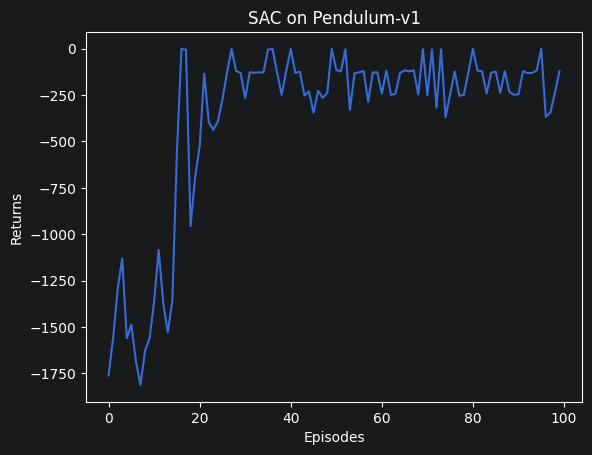

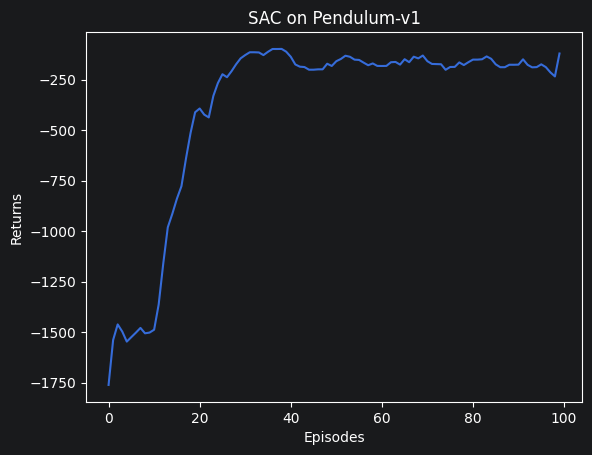

In [6]:
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('SAC on {}'.format(env_name))
plt.show()

mv_return = rl_utils.moving_average(return_list, 9)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('SAC on {}'.format(env_name))
plt.show()